### Pre-requisites


In [13]:
# import needed python libraries

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import statistics
import functions as fnc


## Dataset

we start by importing the pre-processed dataframes generated in section 1 

In [14]:
df_domC = pd.read_pickle('df_domC.pkl')

# Section 3

We analyse by domain knowledge what the websites are providing. Hopefuly we could cluster that put these together. There are 4 labels bellow

| Domain | Primary Label | Notes / Supporting Function |
| :--- | :--- | :--- |
| adnxs.com | **Ad Tech / Analytics** | Advertising Exchange (AppNexus) |
| ads-twitter.com | **Ad Tech / Analytics** | Twitter's advertising platform |
| chartbeat.com | **Ad Tech / Analytics** | Real-time website analytics |
| contextweb.com | **Ad Tech / Analytics** | Contextual advertising platform |
| disqus.com | **Social & Community** | Comment hosting service for websites |
| everesttech.net | **Ad Tech / Analytics** | Adobe advertising/analytics server |
| fastly-insights.com | **Infrastructure & CDN** | Performance monitoring for Fastly CDN |
| fastly.net | **Infrastructure & CDN** | Major Content Delivery Network (CDN) provider |
| ftcdn.net | **Infrastructure & CDN** | CDN for *Financial Times* content |
| giphy.com | **Media Service** | Platform for searching and sharing GIFs |
| githubusercontent.com | **Developer & IT Services** | Raw file & asset hosting for GitHub |
| krxd.net | **Ad Tech / Analytics** | Likely related to advertising or tracking |
| newrelic.com | **Developer & IT Services** | Application performance monitoring (APM) |
| outbrain.com | **Ad Tech / Analytics** | Content recommendation/advertising widget |
| pinterest.com | **Social & Community** | Visual discovery and bookmarking platform |
| polyfill.io | **Developer & IT Services** | Serves JavaScript polyfills for web compatibility |
| redd.it | **Social & Community** | Reddit's link shortener service |
| reddit.com | **Social & Community** | Social news aggregation and discussion forum |
| scdn.co | **Media Service** | SoundCloud's content delivery network for audio |
| slack-edge.com | **Infrastructure & CDN** | CDN for Slack, hosts files and assets |
| taboola.com | **Ad Tech / Analytics** | Content recommendation/advertising platform |
| twimg.com | **Infrastructure & CDN** | Twitter's dedicated image and media CDN |
| twitch.tv | **Media Service** | Live streaming service for gaming and content |
| twitchcdn.net | **Media Service** | Twitch's dedicated content delivery network |
| vimeocdn.com | **Media Service** | Vimeo's content delivery network for video |

In [7]:
import pandas as pd

# Create a dictionary with domain as key and primary label as value
domain_labels = {
    'adnxs.com': 'Ad Tech / Analytics',
    'ads-twitter.com': 'Ad Tech / Analytics',
    'chartbeat.com': 'Ad Tech / Analytics',
    'contextweb.com': 'Ad Tech / Analytics',
    'disqus.com': 'Social & Community',
    'everesttech.net': 'Ad Tech / Analytics',
    'fastly-insights.com': 'Infrastructure & CDN',
    'fastly.net': 'Infrastructure & CDN',
    'ftcdn.net': 'Infrastructure & CDN',
    'giphy.com': 'Media Service',
    'githubusercontent.com': 'Developer & IT Services',
    'krxd.net': 'Ad Tech / Analytics',
    'newrelic.com': 'Developer & IT Services',
    'outbrain.com': 'Ad Tech / Analytics',
    'pinterest.com': 'Social & Community',
    'polyfill.io': 'Developer & IT Services',
    'redd.it': 'Social & Community',
    'reddit.com': 'Social & Community',
    'scdn.co': 'Media Service',
    'slack-edge.com': 'Infrastructure & CDN',
    'taboola.com': 'Ad Tech / Analytics',
    'twimg.com': 'Infrastructure & CDN',
    'twitch.tv': 'Media Service',
    'twitchcdn.net': 'Media Service',
    'vimeocdn.com': 'Media Service',
    '_other' : 'other'
}

# Create DataFrame with domains as index and labels as a column
df_labels = pd.DataFrame.from_dict(domain_labels, orient='index', columns=['Primary_Label'])

# Display the DataFrame
print("DataFrame with domains as index and primary labels:")
print("=" * 60)
print(df_labels)
print("\n" + "=" * 60)
print(f"Total domains: {len(df_labels)}")
print(f"Label distribution:")
print(df_labels['Primary_Label'].value_counts())

# Optional: Add a numeric encoding for the labels if needed for ML
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_labels['Label_Encoded'] = encoder.fit_transform(df_labels['Primary_Label'])



DataFrame with domains as index and primary labels:
                                 Primary_Label
adnxs.com                  Ad Tech / Analytics
ads-twitter.com            Ad Tech / Analytics
chartbeat.com              Ad Tech / Analytics
contextweb.com             Ad Tech / Analytics
disqus.com                  Social & Community
everesttech.net            Ad Tech / Analytics
fastly-insights.com       Infrastructure & CDN
fastly.net                Infrastructure & CDN
ftcdn.net                 Infrastructure & CDN
giphy.com                        Media Service
githubusercontent.com  Developer & IT Services
krxd.net                   Ad Tech / Analytics
newrelic.com           Developer & IT Services
outbrain.com               Ad Tech / Analytics
pinterest.com               Social & Community
polyfill.io            Developer & IT Services
redd.it                     Social & Community
reddit.com                  Social & Community
scdn.co                          Media Service
slack-ed

## 3.1

Exception ignored on calling ctypes callback function <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f54a1caa980>:
Traceback (most recent call last):
  File "/home/tsalvador/Documents/Polito/ML4N-PoliTo/myenv-env/lib64/python3.13/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/tsalvador/Documents/Polito/ML4N-PoliTo/myenv-env/lib64/python3.13/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/home/tsalvador/Documents/Polito/ML4N-PoliTo/myenv-env/lib64/python3.13/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib64/python3.13/ctypes/__init__.py", line 390, in __init__
    f.read().strip()
OSError: dlopen() error


12 features removed


/home/tsalvador/Documents/Polito/ML4N-PoliTo/myenv-env/lib64/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)
/home/tsalvador/Documents/Polito/ML4N-PoliTo/myenv-env/lib64/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:50: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(labels_pred)


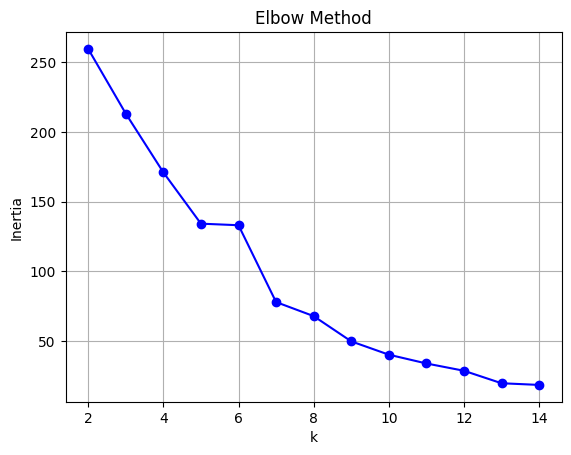

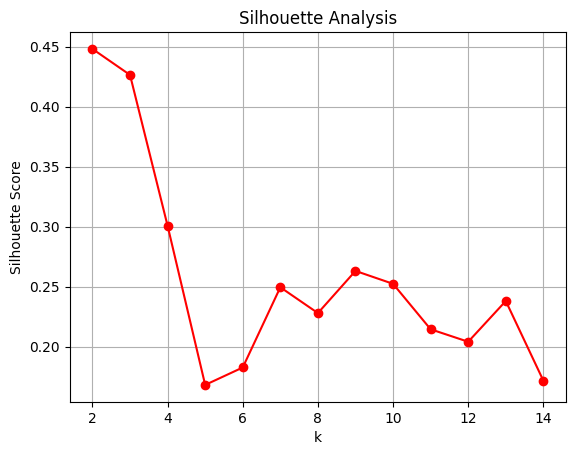

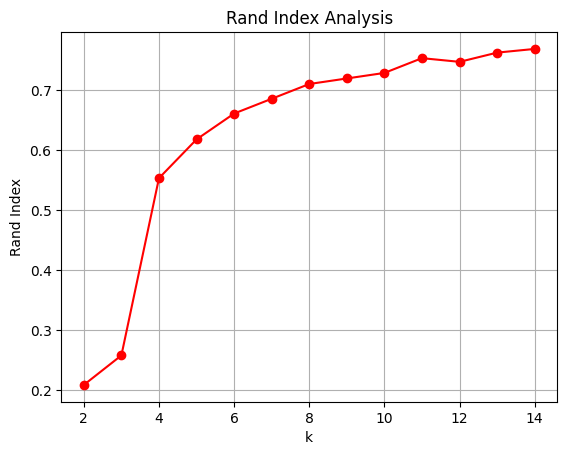

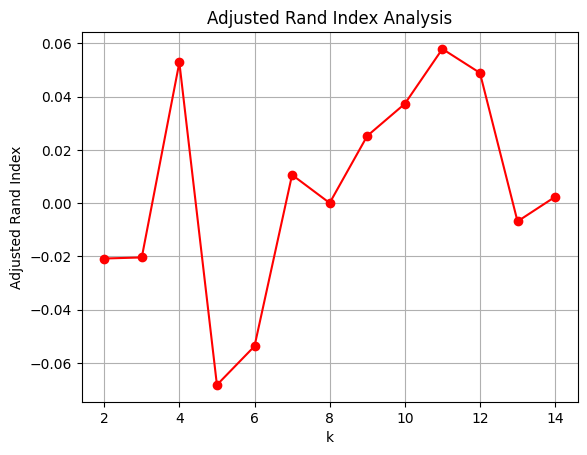

DOMAIN NAMES GROUPED BY CLUSTER

K = 2 CLUSTERS

Cluster 0 (10 domains):
------------------------------
   1. contextweb.com
   2. disqus.com
   3. fastly-insights.com
   4. fastly.net
   5. ftcdn.net
   6. giphy.com
   7. newrelic.com
   8. pinterest.com
   9. redd.it
  10. vimeocdn.com

Cluster 1 (16 domains):
------------------------------
   1. _other
   2. adnxs.com
   3. ads-twitter.com
   4. chartbeat.com
   5. everesttech.net
   6. githubusercontent.com
   7. krxd.net
   8. outbrain.com
   9. polyfill.io
  10. reddit.com
  11. scdn.co
  12. slack-edge.com
  13. taboola.com
  14. twimg.com
  15. twitch.tv
  16. twitchcdn.net

Cluster size distribution:
  Cluster 0: 10 domains
  Cluster 1: 16 domains
  Silhouette Score: 0.1218

K = 3 CLUSTERS

Cluster 0 (5 domains):
------------------------------
   1. fastly-insights.com
   2. ftcdn.net
   3. giphy.com
   4. redd.it
   5. vimeocdn.com

Cluster 1 (3 domains):
------------------------------
   1. _other
   2. scdn.co
   3. slack-e

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, rand_score

X_s, _ = fnc.remove_correlated_features(df_domC, df_domC, correlation_threshold=0.8)

#X_s,_  = remove_correlated_features(df_dom_d, df_dom_d, correlation_threshold=0.7)
#######Tried with PCA and it is just as bad ############
#actualy a lot worse in DBSCAN
#pca = PCA(12)
#X_s = pca.fit_transform(df_domC.dropna())
#plot_corrMat(pd.DataFrame(X_s).corr().abs())
########################################################

# Elbow method
inertias = []
sil_scores = []
RI_scores = []
ARI_scores = []
K_range = range(2, 15)
for k in K_range:
    km = KMeans(n_clusters=k)
    km.fit(X_s)
    inertias.append(km.inertia_)
    labels_km = km.predict(X_s)
    sil_scores.append(silhouette_score(X_s, labels_km))
    ARI_scores.append(adjusted_rand_score(df_labels['Label_Encoded'], labels_km))
    RI_scores.append(rand_score(df_labels['Label_Encoded'], labels_km))

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')   
plt.title('Elbow Method')
plt.grid()

plt.show()

plt.plot(K_range, sil_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()



plt.plot(K_range, RI_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Rand Index')
plt.title('Rand Index Analysis')
plt.show()

plt.plot(K_range, ARI_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Adjusted Rand Index')
plt.title('Adjusted Rand Index Analysis')
plt.show()



print("=" * 60)
print("DOMAIN NAMES GROUPED BY CLUSTER")
print("=" * 60)

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42)
    cluster_labels = km.fit_predict(X_s)
    
    # Create a DataFrame with domain names and their cluster assignments
    cluster_df = pd.DataFrame({
        'domain': df_domC.index,
        'cluster': cluster_labels
    })
    
    print(f"\n{'='*40}")
    print(f"K = {k} CLUSTERS")
    print(f"{'='*40}")
    
    # Group domains by cluster and print
    for cluster_id in range(k):
        domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
        print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
        print("-" * 30)
        
        # Print domains in a readable format (wrap text if needed)
        for i, domain in enumerate(domains_in_cluster, 1):
            print(f"  {i:2d}. {domain}")
    
    # Print some statistics
    cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
    print(f"\nCluster size distribution:")
    for cluster_id, size in cluster_sizes.items():
        print(f"  Cluster {cluster_id}: {size} domains")
    
    # Calculate silhouette score for this k
    sil_score = silhouette_score(X_s, cluster_labels)
    print(f"  Silhouette Score: {sil_score:.4f}")


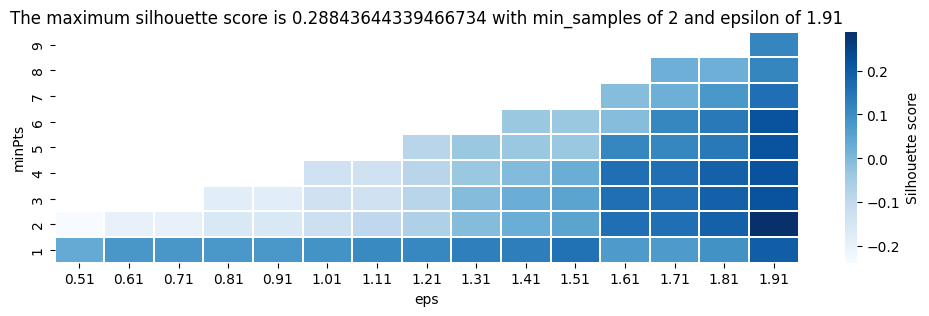

Number of clusters (including noise):  3
Size of each cluster:  [10 14  2]
Silhouette: 0.29
RI: 0.57
ARI: 0.04


In [10]:
from sklearn.cluster import DBSCAN

# Now analyze the performance varying epsilon and min_samples.

shs = []
for eps in np.arange(0.01, 2, 0.1):
    eps = round(eps,3)
    for mins in range(1, 20):
        dbscan = DBSCAN(eps=eps, min_samples=mins)
        cl_labels3 = dbscan.fit_predict(X_s)
        try:
            silhouette  = silhouette_score(X_s, cl_labels3)
        except:
            silhouette = np.nan
        shs.append((eps, mins, silhouette))

gs = pd.DataFrame(shs, columns=['eps', 'minPts', 'sh'])
gs = pd.pivot_table(gs, columns='eps', index='minPts', values='sh', aggfunc=lambda x:x)

# Plot the silhouette score for the different values with a heatmap

plt.figure(figsize=(12,3))
max_ss = gs.max().max()
mins_max_ss = gs.stack().idxmax()[0]
eps_max_ss = gs.stack().idxmax()[1]
plt.title(f'The maximum silhouette score is {max_ss} with min_samples of {mins_max_ss} and epsilon of {eps_max_ss}')
sns.heatmap(gs, cmap='Blues', cbar_kws={'label':'Silhouette score'}, linewidths=.005)
plt.gca().invert_yaxis()
plt.show()

# Report the results of the best combination, also on other metrics

dbscan = DBSCAN(eps=eps_max_ss, min_samples=mins_max_ss )
cl_labels = dbscan.fit_predict(X_s) # Get clusters ID

# Unsupervised metric
silhouette  = silhouette_score(X_s, cl_labels)
# Supervised metrics
ri = rand_score(df_labels['Label_Encoded'], cl_labels)
ari = adjusted_rand_score(df_labels['Label_Encoded'], cl_labels)

# report number and size of each cluster
(unique, counts)=np.unique( cl_labels, return_counts=True)
print("Number of clusters (including noise): ", len(unique))
print("Size of each cluster: ", counts)
# report usupervised and supervised metric
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

In [11]:
pca = PCA(n_components=2)
projection = pca.fit_transform(X_s)
projection = pd.DataFrame(projection)


K = 3 CLUSTERS

Cluster 0 (14 domains):
------------------------------
   1. adnxs.com
   2. ads-twitter.com
   3. contextweb.com
   4. disqus.com
   5. everesttech.net
   6. fastly-insights.com
   7. fastly.net
   8. githubusercontent.com
   9. krxd.net
  10. newrelic.com
  11. outbrain.com
  12. pinterest.com
  13. polyfill.io
  14. taboola.com

Cluster 1 (2 domains):
------------------------------
   1. twitch.tv
   2. twitchcdn.net

Cluster 2 (0 domains):
------------------------------

Cluster size distribution:
  Cluster -1: 10 domains
  Cluster 0: 14 domains
  Cluster 1: 2 domains
  Silhouette Score: 0.2436


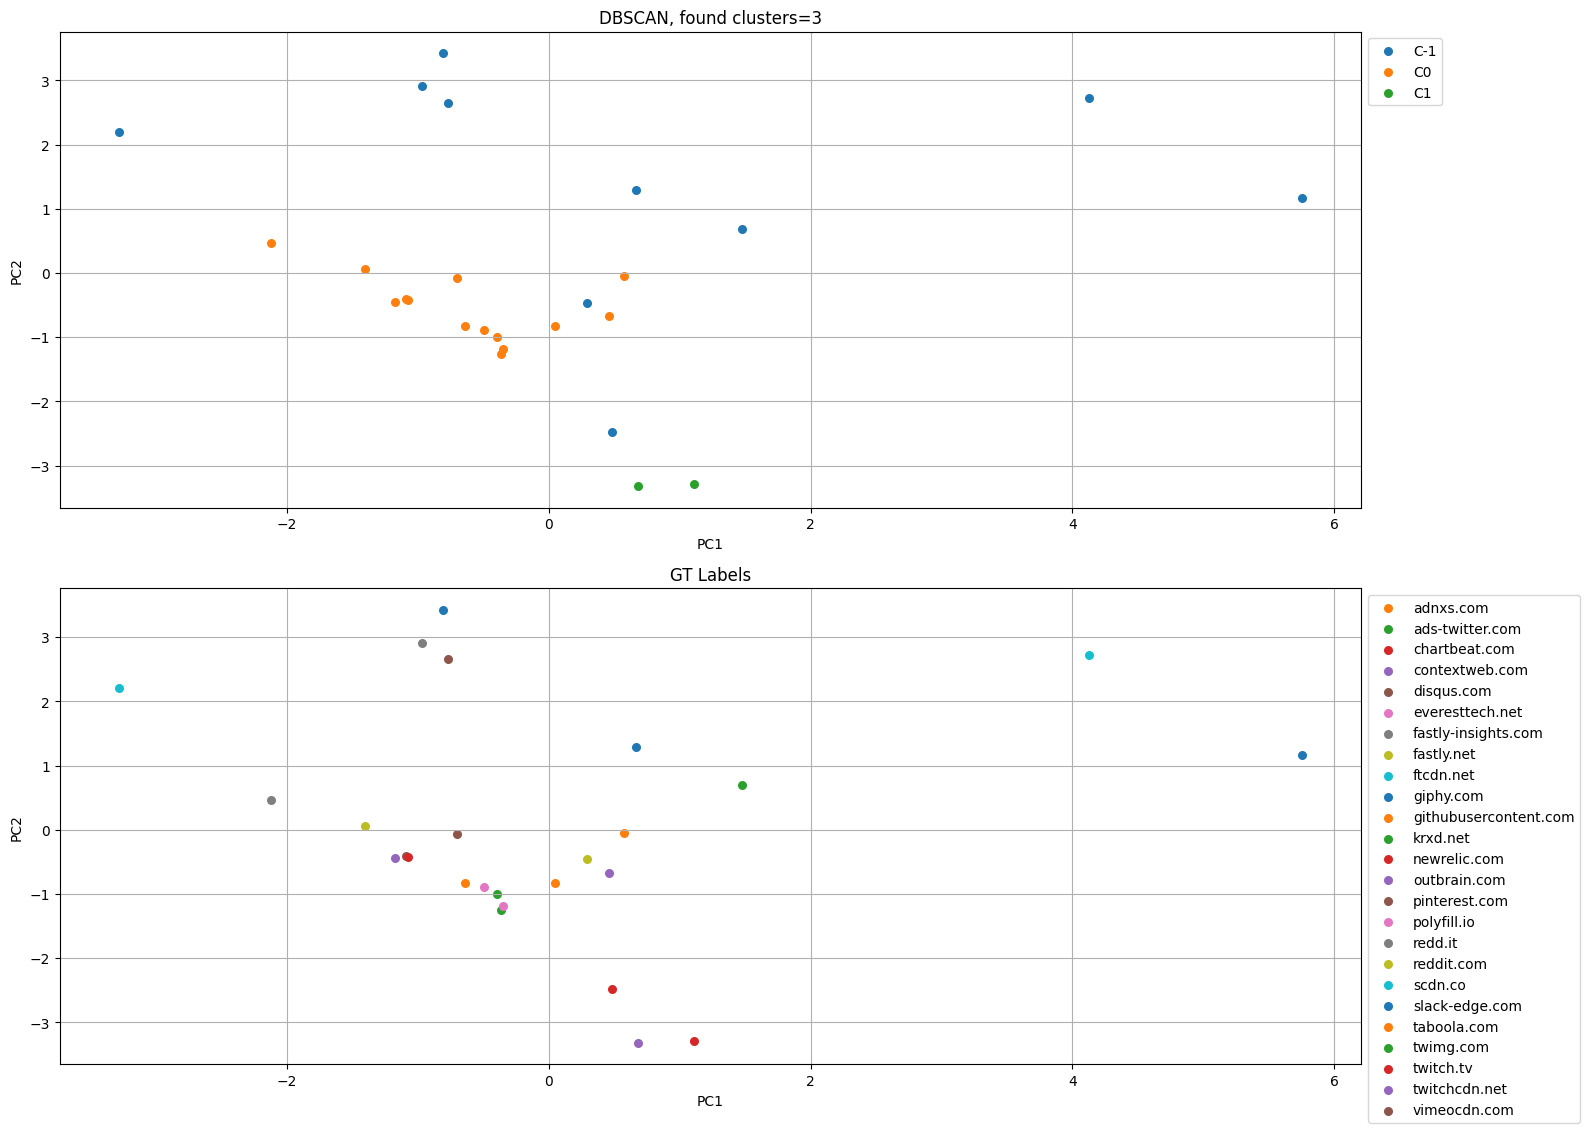

In [12]:
# reuse 2D PCA
# plots

projection['cidBest'] = [f'C{x}' for x in cl_labels]
projection['label'] = df_domC.index

fig, axs = plt.subplots(2, 1, figsize=(16, 12))

for i in np.unique(projection.cidBest):
    subdf = projection[projection.cidBest==i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=30)
axs[0].grid()
lgnd = axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left")

axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title(f'DBSCAN, found clusters={len(unique)}')

for i in np.unique(df_domC.index):
    subdf = projection[projection.label==i]
    axs[1].scatter(subdf[0], subdf[1], label=i, s=30)
axs[1].grid()
lgnd = axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('GT Labels')



# Create a DataFrame with domain names and their cluster assignments
cluster_df = pd.DataFrame({
    'domain': df_domC.index,
    'cluster': cl_labels
})

k = len(unique)
print(f"\n{'='*40}")
print(f"K = {len(unique)} CLUSTERS")
print(f"{'='*40}")

# Group domains by cluster and print
for cluster_id in range(k):
    domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
    print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
    print("-" * 30)
    
    # Print domains in a readable format (wrap text if needed)
    for i, domain in enumerate(domains_in_cluster, 1):
        print(f"  {i:2d}. {domain}")

# Print some statistics
cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
print(f"\nCluster size distribution:")
for cluster_id, size in cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} domains")

# Calculate silhouette score for this k
sil_score = silhouette_score(X_s, cluster_labels)
print(f"  Silhouette Score: {sil_score:.4f}")


plt.tight_layout()
plt.show()